# TextGrad Optimization & Ablation Study

End-to-end results for the LLM-based VC decision pipeline.

| Sections | Content |
|----------|---------|
| 1–5 | TextGrad training: validation metrics, convergence, prompt evolution |
| 6 | Ablation: Random · Single Agent · Multi-analyst · TextGrad |
| 7–8 | LLM-as-judge: reasoning quality scored on 6 dimensions |

Run cells top-to-bottom after any new experiment. To pin a specific judge evaluation run, set `RUN_TIMESTAMP` in the config cell below.

In [87]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
import json
import difflib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Adjust PROJECT_ROOT to point to your Google Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/llm-vc-decision-textgrad/")

In [89]:
# ── Run selection ─────────────────────────────────────────────────────────────

# Set a timestamp to pin a specific run; None = most recent.
# All three share the same value when launched via run_experiments.py.
TG_TIMESTAMP  = "2026-06-21_21-12-56_s42"   # TextGrad run,  e.g. "2026-06-21_10-00-00_s42"
ABL_TIMESTAMP = "2026-06-21_21-12-56_s42"   # Ablation run,  e.g. "2026-06-21_10-00-00_s42"
RUN_TIMESTAMP = "2026-06-21_21-12-56_s42"   # Judge run,     e.g. "2026-06-21_10-00-00_s42"

# ── Resolve base paths from SEED ───────────────────────────────────────────────
_results_base = PROJECT_ROOT / "results"
TG_DIR    = _results_base / "textgrad_validation"
ABL_DIR   = _results_base / "ablation"
JUDGE_DIR = _results_base / "judge_evaluation"

print(f"Results base : {_results_base}")
print(f"  textgrad_validation/ → {TG_DIR}")
print(f"  ablation/            → {ABL_DIR}")
print(f"  judge_evaluation/    → {JUDGE_DIR}\n")

# ── List available runs ────────────────────────────────────────────────────────
def _list_runs(label, runs_dir, selected_ts):
    runs = sorted(
        [p.name for p in runs_dir.glob("*/") if p.is_dir()],
        reverse=True,
    ) if runs_dir.exists() else []
    print(f"{label}:")
    if not runs:
        print("  (no runs yet)")
    else:
        import re
        for ts in runs:
            # Extract seed from timestamp, e.g., '2026-06-21_10-00-00_s42' -> '42'
            seed_match = re.search(r'_s(\d+)$', ts)
            seed_suffix = f" (seed={seed_match.group(1)})" if seed_match else ""

            # Display timestamp without the _sN suffix
            display_ts = ts.rsplit('_s', 1)[0] if seed_match else ts

            marker = "  ← selected (most recent)" if (selected_ts is None and ts == runs[0]) \
                     else ("  ← selected" if ts == selected_ts else "")
            print(f"  {display_ts}{seed_suffix}{marker}")
    print()

_list_runs("TextGrad runs", TG_DIR  / "runs", TG_TIMESTAMP)
_list_runs("Ablation runs", ABL_DIR / "runs", ABL_TIMESTAMP)
_list_runs("Judge runs",    JUDGE_DIR / "runs", RUN_TIMESTAMP)

Results base : /content/drive/MyDrive/llm-vc-decision-textgrad/results
  textgrad_validation/ → /content/drive/MyDrive/llm-vc-decision-textgrad/results/textgrad_validation
  ablation/            → /content/drive/MyDrive/llm-vc-decision-textgrad/results/ablation
  judge_evaluation/    → /content/drive/MyDrive/llm-vc-decision-textgrad/results/judge_evaluation

TextGrad runs:
  2026-06-22_06-45-58 (seed=123)
  2026-06-22_06-21-49
  2026-06-22_06-15-37
  2026-06-21_21-12-56 (seed=42)  ← selected

Ablation runs:
  2026-06-22_06-45-58 (seed=123)
  2026-06-21_21-12-56 (seed=42)  ← selected

Judge runs:
  2026-06-22_06-45-58 (seed=123)
  2026-06-21_21-12-56 (seed=42)  ← selected



## 1. Load TextGrad training results

In [90]:
def _tg_dir():
    """Resolve the TextGrad results directory for the selected run."""
    if TG_TIMESTAMP is not None:
        d = TG_DIR / "runs" / TG_TIMESTAMP
    else:
        latest = TG_DIR / "latest"
        d = latest.resolve() if latest.exists() else TG_DIR
    if not d.exists():
        print(f"⚠  TextGrad run not found: {d}")
    return d

def load_metrics():
    path = _tg_dir() / "metrics_per_step.jsonl"
    if not path.exists():
        return []
    rows = []
    for line in path.read_text().splitlines():
        if line.strip():
            rec = json.loads(line)
            if 'val_metrics' in rec:  # skip per-step training records; keep validation records only
                flat = {**rec, **rec.pop('val_metrics')}
                rows.append(flat)
    print(f"TextGrad metrics : {path}  ({len(rows)} validation steps)")
    return rows

def load_prompts():
    prompts = {}
    d = _tg_dir()
    if d.exists():
        for f in sorted(d.glob("prompt_step_*.txt")):
            step = int(f.stem.split("_")[-1])
            prompts[step] = f.read_text()
    return prompts

def load_final():
    out = {}
    d = _tg_dir()
    if d.exists():
        p = d / "final_metrics.json"
        if p.exists():
            out['metrics'] = json.loads(p.read_text())
        p = d / "final_synthesizer_prompt.txt"
        if p.exists():
            out['prompt'] = p.read_text()
        p = d / "data_splits.json"
        if p.exists():
            out['splits'] = json.loads(p.read_text())
    return out

metrics_data = load_metrics()
prompts      = load_prompts()
final        = load_final()

print(f"TextGrad dir     : {_tg_dir()}")
print(f"Prompt snapshots : {len(prompts)}")
if 'splits' in final:
    s = final['splits']
    print(f"Train / val sizes: {s.get('n_train')} / {s.get('n_val')}  (seed={s.get('seed')})")

TextGrad metrics : /content/drive/MyDrive/llm-vc-decision-textgrad/results/textgrad_validation/runs/2026-06-21_21-12-56_s42/metrics_per_step.jsonl  (3 validation steps)
TextGrad dir     : /content/drive/MyDrive/llm-vc-decision-textgrad/results/textgrad_validation/runs/2026-06-21_21-12-56_s42
Prompt snapshots : 3
Train / val sizes: 3 / 100  (seed=42)


## 2. Validation metrics per training step

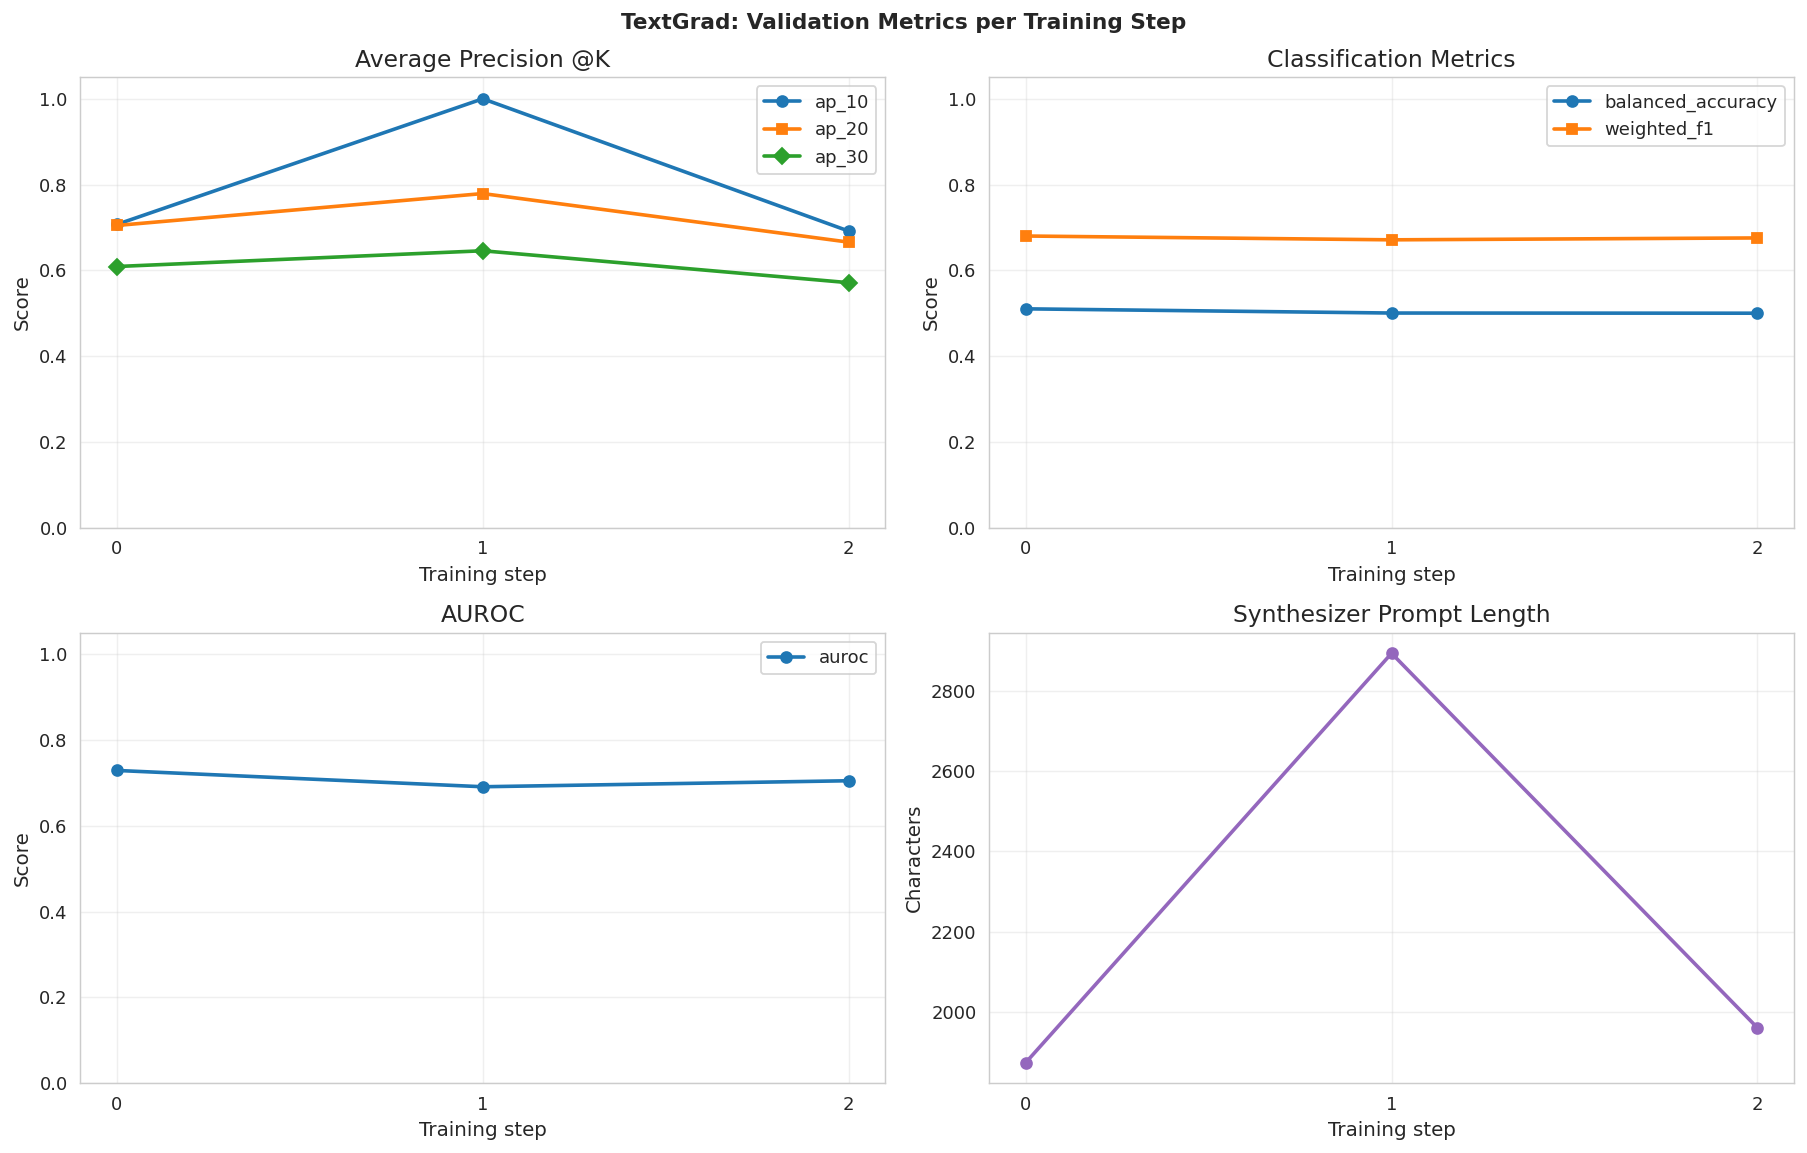

,step,auroc,balanced_accuracy,weighted_f1,ap_10,ap_20,ap_30
0,0,0.7291,0.5102,0.6800,0.7071,0.7046,0.6089
1,1,0.6911,0.5004,0.6711,1.0000,0.7790,0.6456
2,2,0.7051,0.5000,0.6755,0.6915,0.6657,0.5712


In [91]:
if metrics_data:
    df = pd.DataFrame(metrics_data)
    steps = df['step'].tolist() if 'step' in df.columns else list(df.index)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("TextGrad: Validation Metrics per Training Step", fontweight='bold')

    def plot(ax, cols, title):
        for col, marker in zip(cols, 'osDv'):
            if col in df.columns:
                ax.plot(steps, df[col], marker=marker, linewidth=2, label=col)
        ax.set_xlabel('Training step')
        ax.set_ylabel('Score')
        ax.set_title(title)
        ax.set_xticks(steps)
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.grid(alpha=0.3)

    plot(axes[0, 0], ['ap_10', 'ap_20', 'ap_30'],          'Average Precision @K')
    plot(axes[0, 1], ['balanced_accuracy', 'weighted_f1'],  'Classification Metrics')
    plot(axes[1, 0], ['auroc'],                             'AUROC')

    if prompts:
        psteps  = sorted(prompts.keys())
        lengths = [len(prompts[s]) for s in psteps]
        axes[1, 1].plot(psteps, lengths, 'o-', color='tab:purple', linewidth=2)
        axes[1, 1].set_xlabel('Training step')
        axes[1, 1].set_ylabel('Characters')
        axes[1, 1].set_title('Synthesizer Prompt Length')
        axes[1, 1].set_xticks(psteps)
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    display(df[['step', 'auroc', 'balanced_accuracy', 'weighted_f1', 'ap_10', 'ap_20', 'ap_30']].round(4))
else:
    print("⚠️  No metrics found. Run: python experiments/run_textgrad.py --n_train 5 --n_val 5")

## 3. Prompt evolution

In [92]:
if len(prompts) >= 2:
    steps = sorted(prompts.keys())
    print(f"Steps: {steps}")
    print(f"Initial length : {len(prompts[steps[0]])} chars")
    print(f"Final length   : {len(prompts[steps[-1]])} chars\n")

    for i in range(len(steps) - 1):
        a, b = prompts[steps[i]], prompts[steps[i+1]]
        diff = list(difflib.unified_diff(a.splitlines(), b.splitlines(), lineterm=''))
        adds = sum(1 for l in diff if l.startswith('+') and not l.startswith('+++'))
        dels = sum(1 for l in diff if l.startswith('-') and not l.startswith('---'))
        changes = [l for l in diff if l.startswith(('+','-'))
                   and not l.startswith(('+++','---'))]
        print(f"Step {steps[i]} → {steps[i+1]}:  +{adds} lines  -{dels} lines")
        for c in changes[:3]:
            sym = '➕' if c[0] == '+' else '➖'
            print(f"   {sym} {c[1:]}")
        print()
else:
    print("No prompt snapshots found yet.")


Steps: [0, 1, 2]
Initial length : 1873 chars
Final length   : 1960 chars

Step 0 → 1:  +2 lines  -2 lines
   ➖ You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts and must synthesize their perspectives into a single investment recommendation, prioritizing caution and carefully evaluating the potential risks and benefits. When evaluating the startup, consider the following factors: team credentials, market opportunity, business model, product viability, and traction. Use the following evaluation framework to assess the startup: team credentials (20%), market opportunity (20%), business model (20%), product viability (20%), and traction (20%). Only invest in startups with a probability of success above 70% and at least three promising assessments from the four analysts. Provide a detailed explanation of the decision, including the key factors that influenced the outcome and the weight assigned to each factor. Addit

## 4. Initial vs. final prompt (full diff)

In [93]:
if len(prompts) >= 2:
    steps = sorted(prompts.keys())
    initial, final_p = prompts[steps[0]], prompts[steps[-1]]
    diff = difflib.unified_diff(
        initial.splitlines(keepends=True),
        final_p.splitlines(keepends=True),
        fromfile=f'step_{steps[0]}',
        tofile=f'step_{steps[-1]}',
    )
    print(''.join(diff))
else:
    print("Need at least 2 prompt snapshots.")


--- step_0
+++ step_2
@@ -1,13 +1,4 @@
-You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts and must synthesize their perspectives into a single investment recommendation, prioritizing caution and carefully evaluating the potential risks and benefits. When evaluating the startup, consider the following factors: team credentials, market opportunity, business model, product viability, and traction. Use the following evaluation framework to assess the startup: team credentials (20%), market opportunity (20%), business model (20%), product viability (20%), and traction (20%). Only invest in startups with a probability of success above 70% and at least three promising assessments from the four analysts. Provide a detailed explanation of the decision, including the key factors that influenced the outcome and the weight assigned to each factor. Additionally, provide a risk assessment of the startup, including potential 

## 5. Ablation study

In [114]:
def _abl_dir():
    """Resolve the ablation results directory for the selected run."""
    if ABL_TIMESTAMP is not None:
        return ABL_DIR / "runs" / ABL_TIMESTAMP
    latest = ABL_DIR / "latest"
    return latest.resolve() if latest.exists() else ABL_DIR

def load_ablation_metrics(prefix: str) -> list[dict] | None:
    base = _abl_dir()

    # Define the strict filter for files that end with '_metrics.json'
    # but specifically do NOT contain '_sector_metrics.json'
    def _strict_metrics_filter(file_paths):
        return [
            f for f in file_paths
            if f.name.endswith("_metrics.json") and "_sector_metrics.json" not in f.name
        ]

    # 1. Search in the current ablation directory
    # Glob broadly for all .json files to then apply strict filter
    all_json_files_in_base = sorted(base.glob(f"{prefix}*.json"))
    files = _strict_metrics_filter(all_json_files_in_base)

    if not files: # If no strictly-defined _metrics.json found in current run dir
        # 2. Search other runs/ subdirs newest-first
        runs_dir = ABL_DIR / "runs"
        if runs_dir.exists():
            for d in sorted(runs_dir.iterdir(), key=lambda p: p.stat().st_mtime, reverse=True):
                all_json_files_in_run = sorted(d.glob(f"{prefix}*.json"))
                files = _strict_metrics_filter(all_json_files_in_run)
                if files: # Found valid _metrics.json in another run
                    break

    if not files: # If still no strictly-defined _metrics.json found
        # 3. Search archive/ structure
        archive_dir = ABL_DIR / "archive"
        if archive_dir.exists():
            for d in sorted(archive_dir.iterdir(), reverse=True):
                if d.is_dir():
                    all_json_files_in_archive = sorted(d.glob(f"{prefix}*.json"))
                    files = _strict_metrics_filter(all_json_files_in_archive)
                    if files: # Found valid _metrics.json in archive
                        break

    if not files:
        # No *_metrics.json file (excluding _sector_metrics.json) found for this prefix
        print(f"  {prefix:<10} (No *_metrics.json file found matching criteria)")
        return None

    path = files[-1]
    print(f"  {prefix:<10} {path.relative_to(PROJECT_ROOT)}")
    with open(path) as f:
        loaded_data = json.load(f)

    metric_row = loaded_data.copy()
    metric_row['Sector'] = '_overall_'
    return [metric_row]

print(f"Ablation dir : {_abl_dir()}\n")
# The 'raw_conditions_data' dictionary will now store lists of metric dictionaries
# (either per-sector or a single '_overall_' entry if _metrics.json was loaded)
raw_conditions_data = {
    'Random':   load_ablation_metrics('random_'),
    'Single':   load_ablation_metrics('single_'),
    'Multi':    load_ablation_metrics('multi_'),
    'TextGrad': load_ablation_metrics('textgrad_'),
}

print()

Ablation dir : /content/drive/MyDrive/llm-vc-decision-textgrad/results/ablation/runs/2026-06-21_21-12-56_s42

  random_    results/ablation/runs/2026-06-21_21-12-56_s42/random_val_metrics.json
  single_    results/ablation/runs/2026-06-21_21-12-56_s42/single_val_ollama_glm4:latest_metrics.json
  multi_     results/ablation/runs/2026-06-21_21-12-56_s42/multi_val_ollama_glm4:latest_metrics.json
  textgrad_  results/ablation/runs/2026-06-21_21-12-56_s42/textgrad_val_ollama_glm4:latest_metrics.json



,auroc,balanced_accuracy,weighted_f1,ap_10,ap_20,ap_30
Condition,,,,,,
Random,0.5314,0.5604,0.5769,0.2211,0.2455,0.2773
Single,0.6918,0.6288,0.5957,0.8664,0.7781,0.6999
Multi,0.6896,0.6808,0.7350,1.0000,0.7126,0.6505
TextGrad,0.6184,0.4928,0.6522,0.7071,0.6461,0.5593


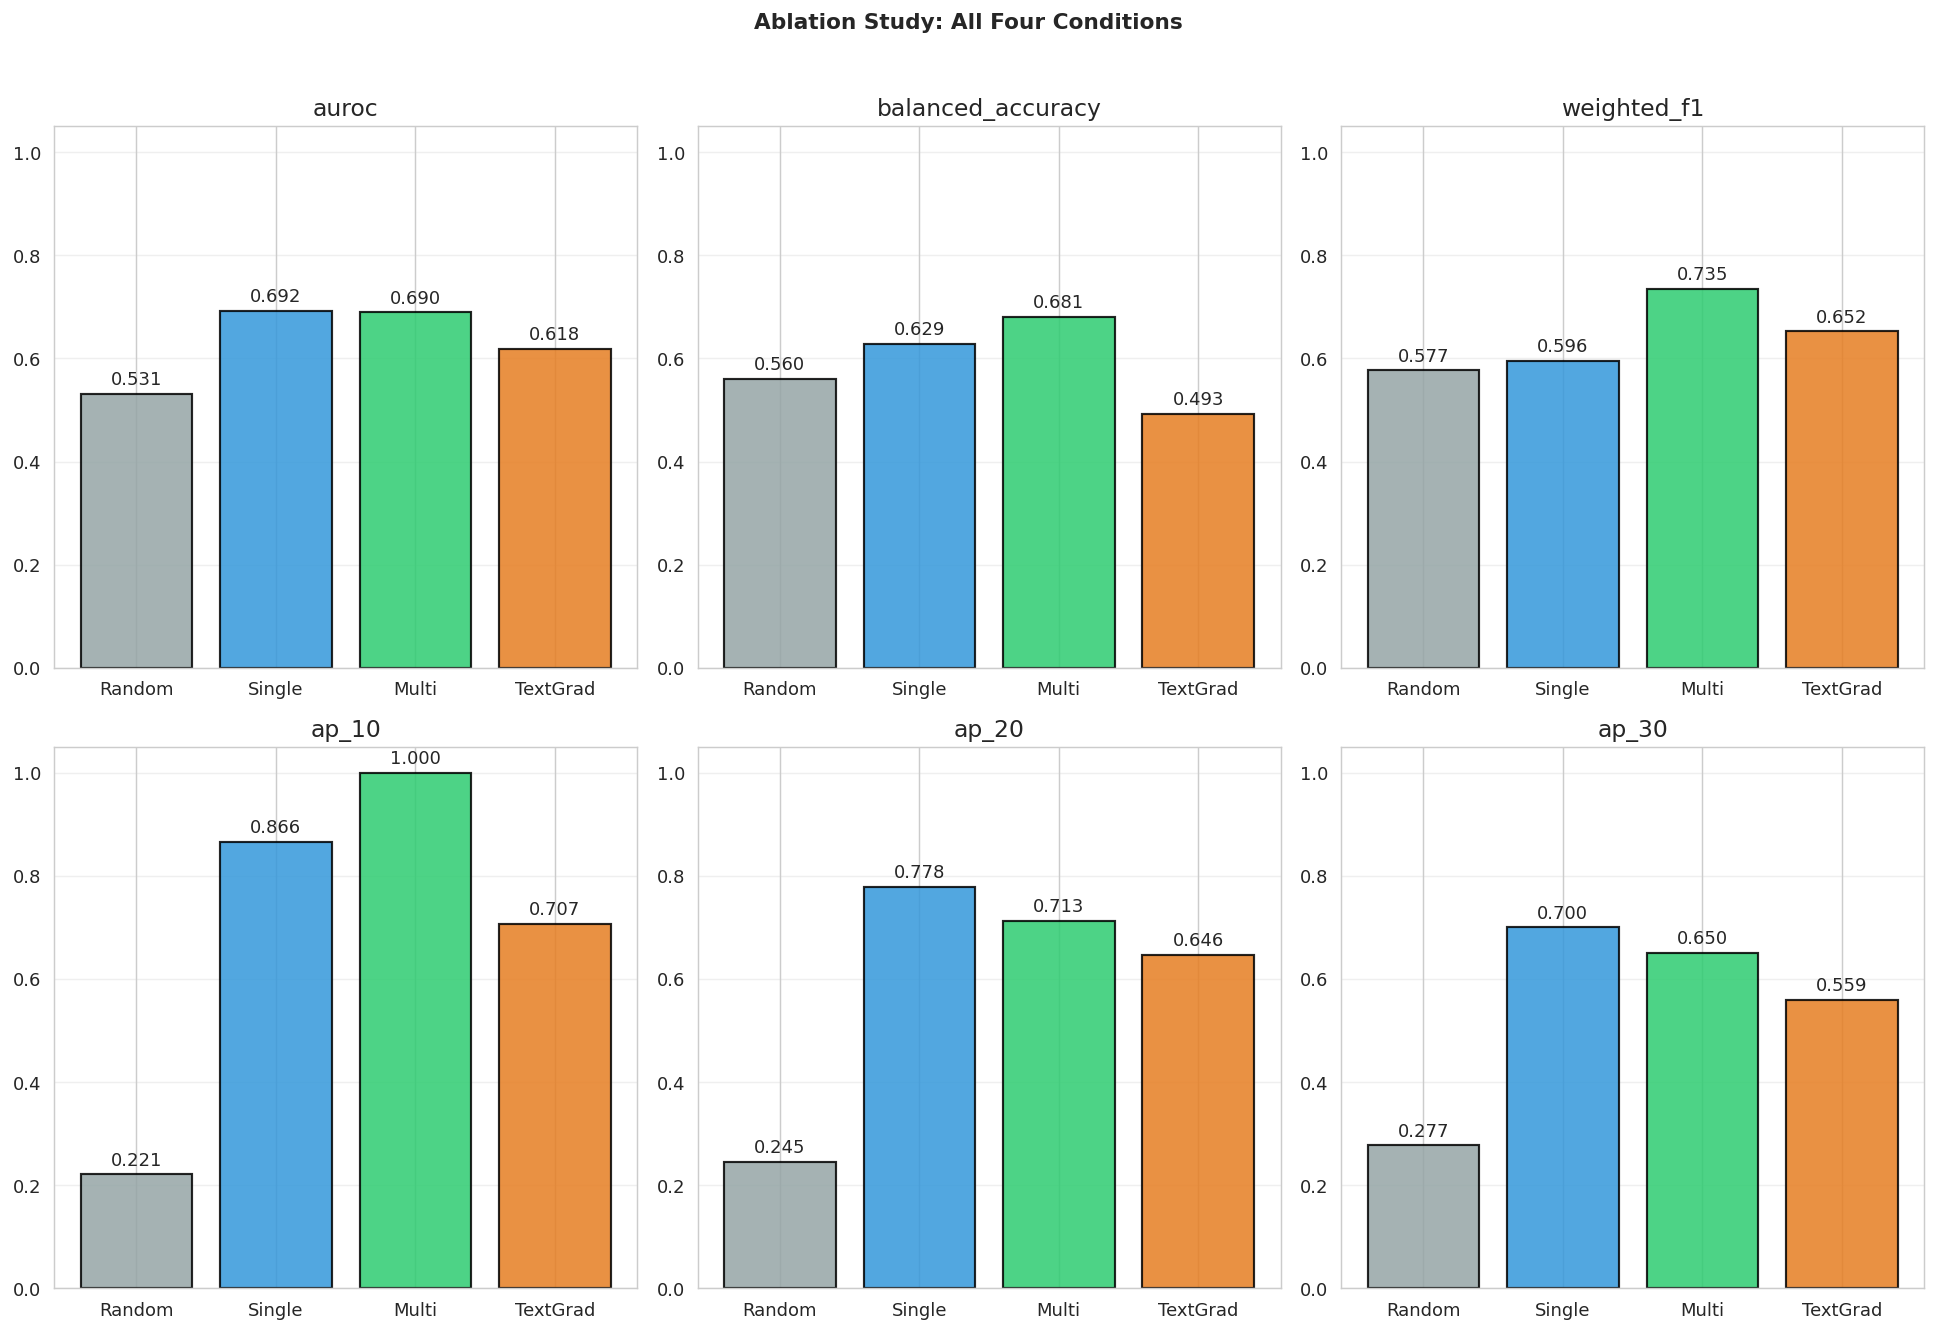

In [124]:
available_raw_data = {k: v for k, v in raw_conditions_data.items() if v is not None}

if available_raw_data:
    metrics_to_show = ['auroc', 'balanced_accuracy', 'weighted_f1', 'ap_10', 'ap_20', 'ap_30']
    all_rows = []

    for condition_name, list_of_metric_dicts in available_raw_data.items():
        for metrics_dict in list_of_metric_dicts:
            # Ensure 'weighted_f1' exists if 'f1' does
            if 'weighted_f1' not in metrics_dict and 'f1' in metrics_dict:
                metrics_dict['weighted_f1'] = metrics_dict['f1']

            row = {'Condition': condition_name, 'Sector': metrics_dict['Sector']}
            for met in metrics_to_show:
                row[met] = metrics_dict.get(met, float('nan'))
            all_rows.append(row)

    cmp_raw = pd.DataFrame(all_rows)
    cmp_raw = cmp_raw.set_index(['Condition', 'Sector'])


    # Since they are already aggregated and load_ablation_metrics adds '_overall_',
    # we just need to droplevel 'Sector' to prepare for plotting.
    cmp_plot = cmp_raw.droplevel('Sector')

    display(cmp_plot.round(4))

    plot_metrics = [m for m in metrics_to_show if m in cmp_plot.columns]
    ncols = 3
    nrows = (len(plot_metrics) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()

    palette = {'Random': '#95a5a6', 'Single': '#3498db', 'Multi': '#2ecc71', 'TextGrad': '#e67e22'}
    for ax, met in zip(axes, plot_metrics):
        vals = cmp_plot[met]
        colors = [palette.get(c, 'steelblue') for c in vals.index]
        bars = ax.bar(vals.index, vals.values, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
        ax.set_ylim(0, 1.05)
        ax.set_title(met)
        ax.grid(axis='y', alpha=0.3)
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.3f}',
                        ha='center', va='bottom', fontsize=10)

    for ax in axes[len(plot_metrics):]:  # hide unused subplots
        ax.set_visible(False)

    plt.suptitle("Ablation Study: All Four Conditions", fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No ablation results found yet.")
    print("Run:  python experiments/run_experiments.py")

## 6. LLM-as-judge: reasoning quality

Scores reasoning quality on 6 dimensions grounded in Schumpeter's innovation theory and VC evaluation criteria, across the single-agent, multi-analyst, and TextGrad conditions.

In [118]:
def _pick_judge_file(filename: str) -> Path | None:
    """Return the path to a judge output file for the selected run."""
    runs_dir = JUDGE_DIR / "runs"

    if runs_dir.exists():
        run_dirs = sorted(runs_dir.iterdir(), key=lambda p: p.stat().st_mtime)
        if RUN_TIMESTAMP is not None:
            match = [p for p in run_dirs if p.name == RUN_TIMESTAMP]
            if not match:
                print(f"⚠  No judge run with timestamp '{RUN_TIMESTAMP}'")
                return None
            p = match[0] / filename
            return p if p.exists() else None
        # Most recent run
        for d in reversed(run_dirs):
            p = d / filename
            if p.exists():
                return p

    # Legacy fallback: files with timestamp baked into filename
    if filename == "judge_scores.jsonl":
        legacy = sorted(JUDGE_DIR.glob("judge_scores_*.jsonl"), key=lambda p: p.stat().st_mtime)
        if legacy:
            if RUN_TIMESTAMP is not None:
                match = [f for f in legacy if RUN_TIMESTAMP in f.name]
                return match[-1] if match else None
            return legacy[-1]
    if filename == "judge_summary.json":
        legacy = sorted(JUDGE_DIR.glob("judge_summary_*.json"), key=lambda p: p.stat().st_mtime)
        if legacy:
            if RUN_TIMESTAMP is not None:
                match = [f for f in legacy if RUN_TIMESTAMP in f.name]
                return match[-1] if match else None
            return legacy[-1]
    return None

def load_latest_judge_scores() -> pd.DataFrame | None:
    path = _pick_judge_file("judge_scores.jsonl")
    if path is None:
        return None
    rows = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
    print(f"Judge scores  : {path.relative_to(PROJECT_ROOT)}  ({len(rows)} records)")
    return pd.DataFrame(rows)

def load_latest_judge_summary() -> pd.DataFrame | None:
    path = _pick_judge_file("judge_summary.json")
    if path is None:
        return None
    print(f"Judge summary : {path.relative_to(PROJECT_ROOT)}")
    return pd.read_json(path)

judge_df   = load_latest_judge_scores()
judge_smry = load_latest_judge_summary()

Judge scores  : results/judge_evaluation/runs/2026-06-21_21-12-56_s42/judge_scores.jsonl  (30 records)
Judge summary : results/judge_evaluation/runs/2026-06-21_21-12-56_s42/judge_summary.json


Average scores by condition (1–5 scale):



,product novelty,market opportunity,feasibility,team quality,reasoning coherence,risk identification,total_score
single,2.0,2.8,3.3,3.3,4.0,3.1,18.5
multi,3.3,4.2,3.5,3.0,4.2,4.0,22.2
textgrad,2.2,3.1,2.7,1.7,3.6,3.3,16.6


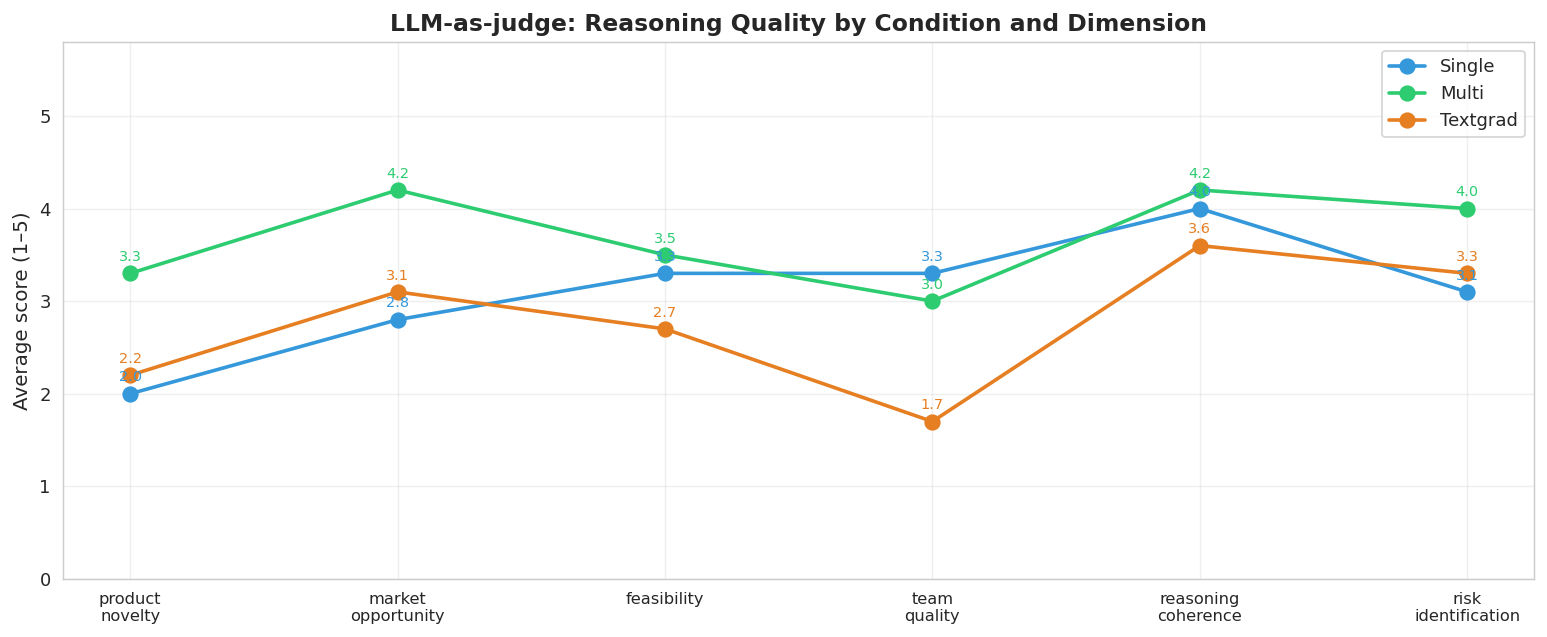

In [119]:
if judge_smry is not None:
    dims = ['product novelty','market opportunity','feasibility',
            'team quality','reasoning coherence','risk identification']
    available_dims = [d for d in dims if d in judge_smry.columns]

    print("Average scores by condition (1–5 scale):\n")
    display(judge_smry[available_dims + ['total_score']].round(2) if 'total_score' in judge_smry.columns
            else judge_smry[available_dims].round(2))

    order = [c for c in ['single','multi','textgrad'] if c in judge_smry.index]
    palette = {'single':'#3498db','multi':'#2ecc71','textgrad':'#e67e22'}

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(available_dims))

    for cond in order:
        vals = [judge_smry.loc[cond, d] if d in judge_smry.columns else 0 for d in available_dims]
        ax.plot(x, vals, 'o-', linewidth=2, markersize=8,
                label=cond.capitalize(), color=palette.get(cond))
        for xi, v in zip(x, vals):
            ax.text(xi, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=8,
                    color=palette.get(cond))

    ax.set_xticks(x)
    ax.set_xticklabels([d.replace(' ', '\n') for d in available_dims], fontsize=9)
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Average score (1–5)')
    ax.set_title('LLM-as-judge: Reasoning Quality by Condition and Dimension', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No judge results found. Run: python experiments/run_judge_evaluation.py --n_sample 10")

In [98]:
# Per-startup breakdown
if judge_df is not None and not judge_df.empty:
    score_cols = [c for c in judge_df.columns if c.endswith('_score')]
    print("Per-startup scores by condition:\n")
    for obj_id in judge_df['object_id'].unique():
        sub = judge_df[judge_df['object_id'] == obj_id]
        name   = sub['name'].iloc[0]
        target = 'INVEST' if sub['target'].iloc[0] == 1 else 'PASS'
        print(f"{name} (ground truth: {target})")
        for _, row in sub.iterrows():
            scores = '  '.join(f"{c.replace('_score','')[:4]}={int(row[c])}" for c in score_cols if c in row)
            print(f"  [{row['condition']:9s}] decision={row.get('decision','?'):5s}  {scores}  total={int(row['total_score'])}")
        print()


Per-startup scores by condition:

GigPark (ground truth: INVEST)
  [single   ] decision=PASS   prod=2  mark=3  feas=4  team=4  reas=4  risk=4  tota=21  total=21
  [multi    ] decision=PASS   prod=4  mark=4  feas=3  team=2  reas=4  risk=4  tota=21  total=21
  [textgrad ] decision=PASS   prod=2  mark=3  feas=3  team=2  reas=4  risk=4  tota=18  total=18

Bloggerce (ground truth: PASS)
  [single   ] decision=PASS   prod=2  mark=4  feas=3  team=4  reas=4  risk=4  tota=21  total=21
  [multi    ] decision=PASS   prod=2  mark=3  feas=3  team=3  reas=4  risk=4  tota=19  total=19
  [textgrad ] decision=PASS   prod=2  mark=3  feas=2  team=2  reas=4  risk=4  tota=17  total=17

Picnik (ground truth: INVEST)
  [single   ] decision=INVEST  prod=2  mark=3  feas=3  team=1  reas=4  risk=1  tota=14  total=14
  [multi    ] decision=INVEST  prod=3  mark=5  feas=4  team=2  reas=4  risk=3  tota=21  total=21
  [textgrad ] decision=PASS   prod=2  mark=4  feas=3  team=3  reas=4  risk=4  tota=20  total=20

Local

## 8. Score gains, radar chart, and progression

In [120]:
# ── Reload judge summary (safe if section 7 wasn't run) ──────────────────────
try:
    _smry = judge_smry
except NameError:
    _smry = None

if _smry is None:
    path = _pick_judge_file("judge_summary.json")
    _smry = pd.read_json(path) if path else None

DIMS = ['product novelty', 'market opportunity', 'feasibility',
        'team quality', 'reasoning coherence', 'risk identification']
DIMS = [d for d in DIMS if _smry is not None and d in _smry.columns]
ORDER = [c for c in ['single', 'multi', 'textgrad'] if _smry is not None and c in _smry.index]
PALETTE = {'single': '#3498db', 'multi': '#2ecc71', 'textgrad': '#e67e22'}

print(f"Conditions: {ORDER}")
print(f"Dimensions: {DIMS}")
if _smry is not None:
    display(_smry[DIMS + (['total_score'] if 'total_score' in _smry.columns else [])].round(2))

Conditions: ['single', 'multi', 'textgrad']
Dimensions: ['product novelty', 'market opportunity', 'feasibility', 'team quality', 'reasoning coherence', 'risk identification']


,product novelty,market opportunity,feasibility,team quality,reasoning coherence,risk identification,total_score
single,2.0,2.8,3.3,3.3,4.0,3.1,18.5
multi,3.3,4.2,3.5,3.0,4.2,4.0,22.2
textgrad,2.2,3.1,2.7,1.7,3.6,3.3,16.6


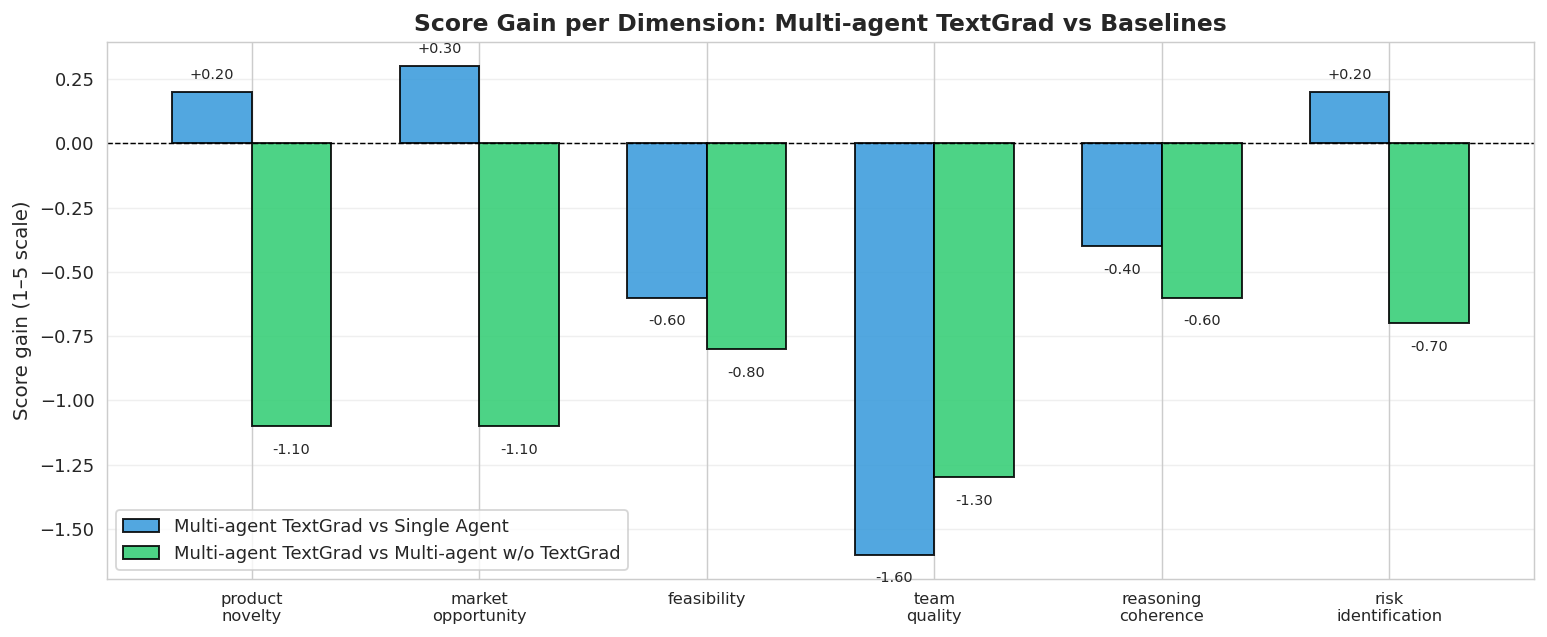

In [121]:
# ── Score gain per dimension ──────────────────────────────────────────────────
if _smry is not None and 'textgrad' in ORDER:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(DIMS))
    width = 0.35

    baseline_labels = {
        'single': 'Multi-agent TextGrad vs Single Agent',
        'multi':  'Multi-agent TextGrad vs Multi-agent w/o TextGrad',
    }
    baselines = [c for c in ['single', 'multi'] if c in ORDER]
    offsets = np.linspace(-width/2 * (len(baselines)-1), width/2 * (len(baselines)-1), len(baselines))

    for offset, base in zip(offsets, baselines):
        deltas = [_smry.loc['textgrad', d] - _smry.loc[base, d] for d in DIMS]
        bars = ax.bar(x + offset, deltas, width, label=baseline_labels[base],
                      color=PALETTE[base], alpha=0.85, edgecolor='black', linewidth=1.1)
        for bar in bars:
            h = bar.get_height()
            ypos = h + 0.04 if h >= 0 else h - 0.12
            ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{h:+.2f}',
                    ha='center', va='bottom', fontsize=8)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([d.replace(' ', '\n') for d in DIMS], fontsize=9)
    ax.set_ylabel('Score gain (1–5 scale)')
    ax.set_title('Score Gain per Dimension: Multi-agent TextGrad vs Baselines', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

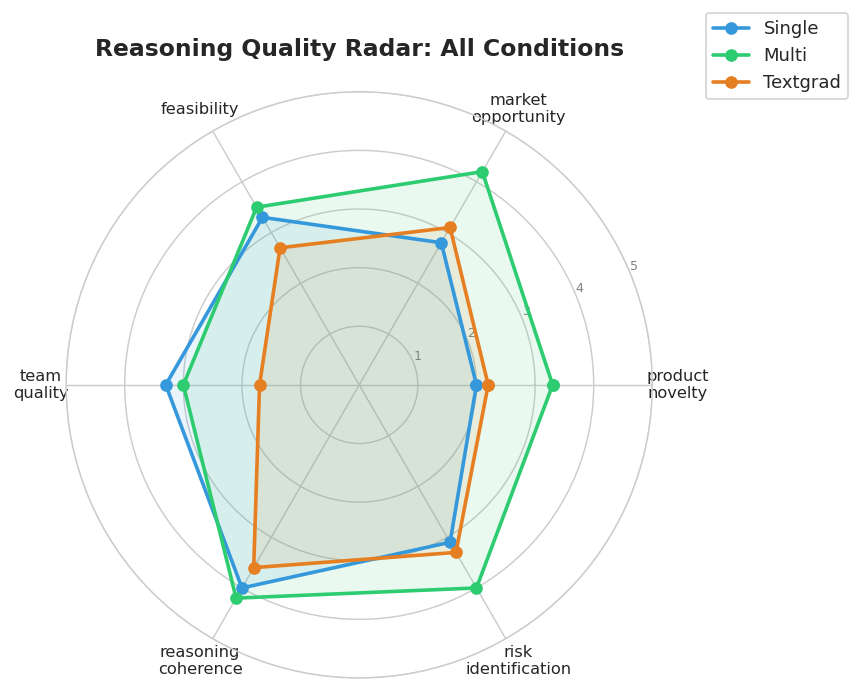

In [122]:
# ── Radar chart ───────────────────────────────────────────────────────────────
if _smry is not None:
    N = len(DIMS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})

    for cond in ORDER:
        vals = [_smry.loc[cond, d] for d in DIMS] + [_smry.loc[cond, DIMS[0]]]
        ax.plot(angles, vals, 'o-', linewidth=2, label=cond.capitalize(), color=PALETTE[cond])
        ax.fill(angles, vals, alpha=0.10, color=PALETTE[cond])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([d.replace(' ', '\n') for d in DIMS], size=9)
    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], size=7, color='grey')
    ax.set_title('Reasoning Quality Radar: All Conditions', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
    plt.tight_layout()
    plt.show()

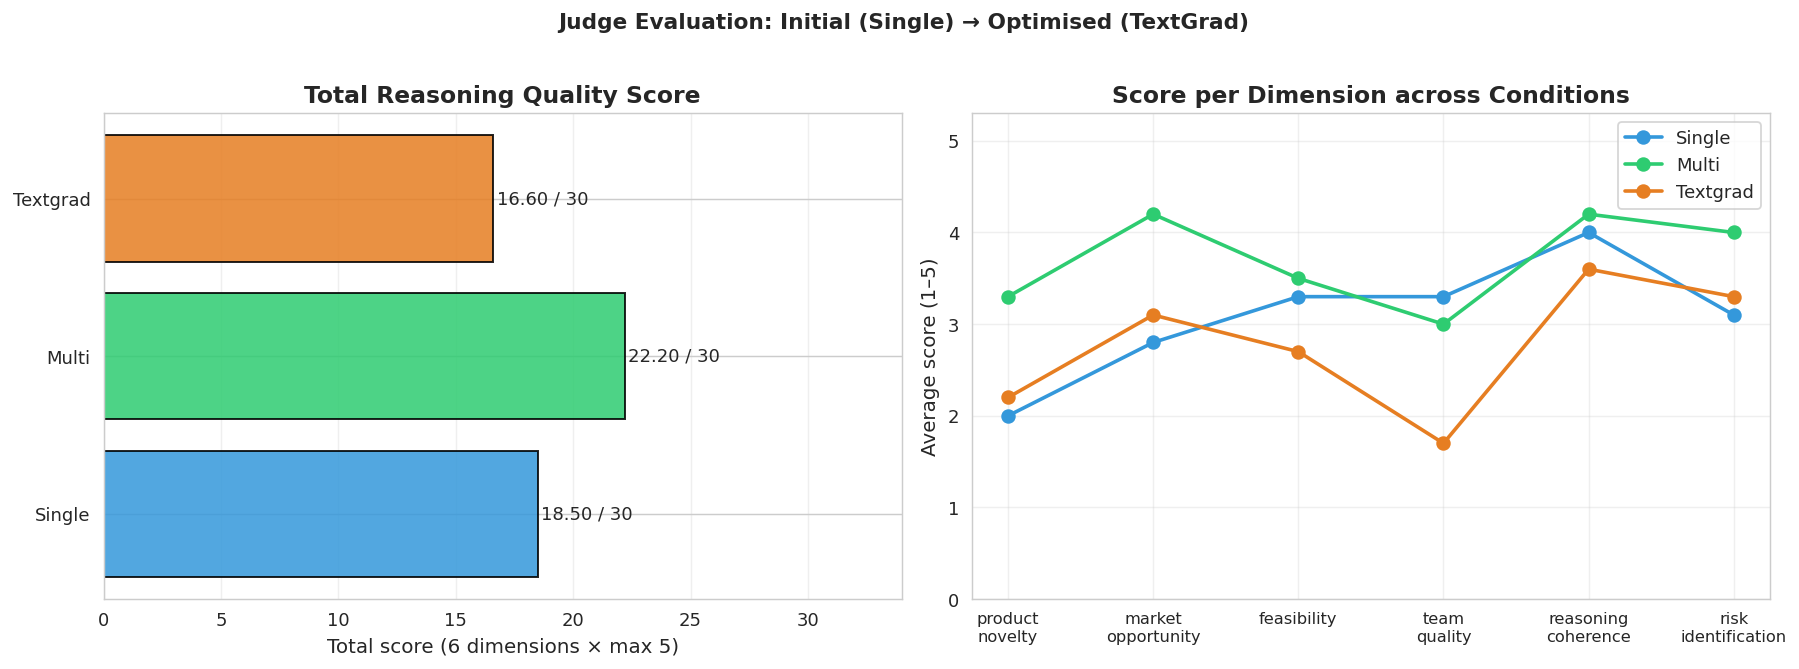

In [123]:
# ── Initial vs final total scores + per-dimension progression ─────────────────
if _smry is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: total score comparison
    if 'total_score' in _smry.columns:
        totals = [_smry.loc[c, 'total_score'] for c in ORDER]
        colors = [PALETTE[c] for c in ORDER]
        bars = ax1.barh([c.capitalize() for c in ORDER], totals,
                        color=colors, alpha=0.85, edgecolor='black', linewidth=1.1)
        for bar, val in zip(bars, totals):
            ax1.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
                     f'{val:.2f} / 30', va='center', fontsize=10)
        ax1.set_xlim(0, 34)
        ax1.set_xlabel('Total score (6 dimensions × max 5)')
        ax1.set_title('Total Reasoning Quality Score', fontweight='bold')
        ax1.grid(axis='x', alpha=0.3)

    # Right: per-dimension score across conditions (line, treating as progression)
    x = np.arange(len(DIMS))
    for cond in ORDER:
        vals = [_smry.loc[cond, d] for d in DIMS]
        ax2.plot(x, vals, 'o-', linewidth=2, label=cond.capitalize(),
                 color=PALETTE[cond], markersize=7)

    ax2.set_xticks(x)
    ax2.set_xticklabels([d.replace(' ', '\n') for d in DIMS], fontsize=9)
    ax2.set_ylim(0, 5.3)
    ax2.set_ylabel('Average score (1–5)')
    ax2.set_title('Score per Dimension across Conditions', fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Judge Evaluation: Initial (Single) → Optimised (TextGrad)', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()